# Prime Trade AI Assignment
# Trader Performance vs Bitcoin Market Sentiment


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns",None)

Upload files

In [2]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


Read datasets

In [3]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [4]:
print(trades.shape)
print(sentiment.shape)

trades.head()

(211224, 16)
(2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Dataset information

In [6]:
trades.info()

sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

Missing values

In [7]:
print(trades.isnull().sum())

print()

print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

timestamp         0
value             0
classification    0
date              0
dtype: int64


Duplicate rows

In [8]:
print("Trade duplicates :",trades.duplicated().sum())

print("Sentiment duplicates :",sentiment.duplicated().sum())

Trade duplicates : 0
Sentiment duplicates : 0


Convert date columns

In [14]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)
trades["Date"] = trades["Timestamp IST"].dt.date

In [15]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date

Merge datasets

In [16]:
merged = pd.merge(
    trades,
    sentiment[["Date","classification","value"]],
    on="Date",
    how="left"
)

Rename columns

In [17]:
merged.rename(columns={
    "classification":"Market Sentiment",
    "value":"FearGreedIndex"
},inplace=True)

In [18]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,Market Sentiment,FearGreedIndex
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


Save merged dataset

In [19]:
merged.to_csv("merged_dataset.csv",index=False)

Statistics

In [20]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,FearGreedIndex
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784


Distribution of sentiment

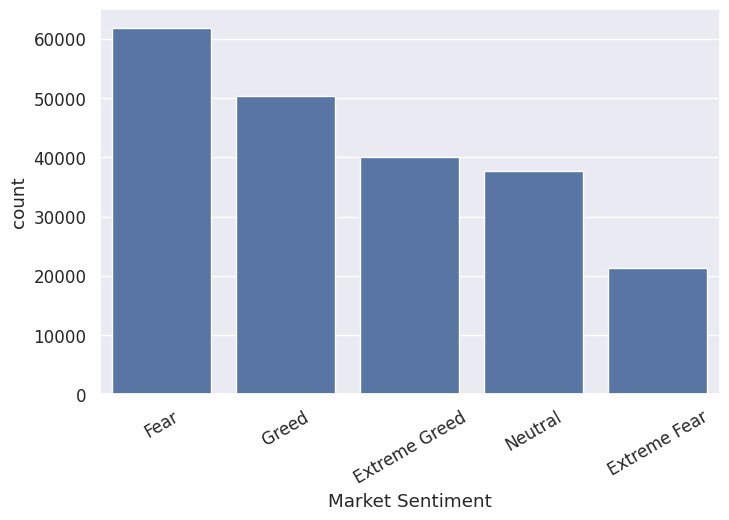

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="Market Sentiment",
    order=merged["Market Sentiment"].value_counts().index
)

plt.xticks(rotation=30)

plt.show()

Distribution of PnL

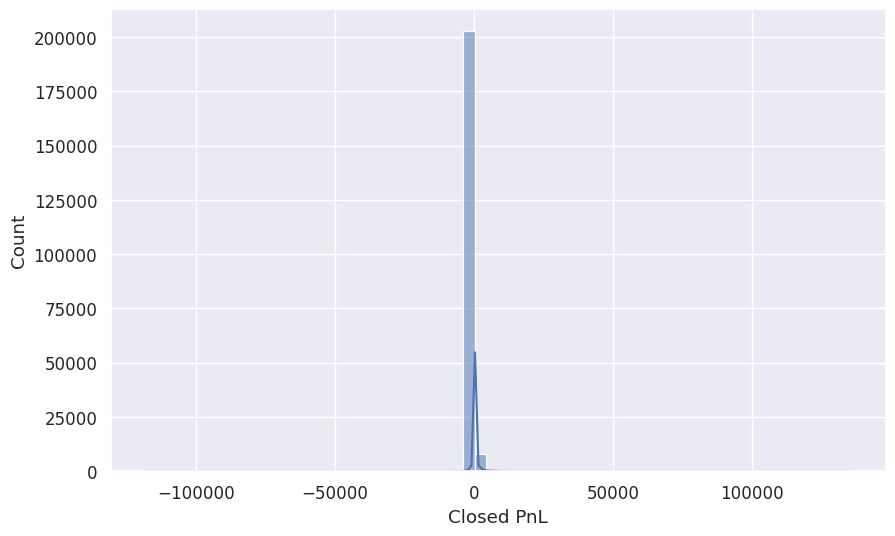

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    merged["Closed PnL"],
    bins=60,
    kde=True
)

plt.show()

Leverage distribution

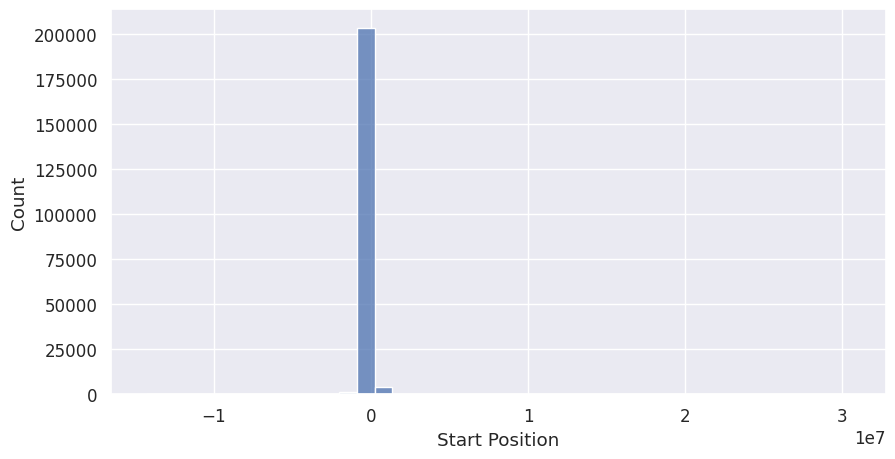

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(merged["Start Position"],bins=40)

plt.show()

Average PnL by sentiment

In [24]:
avg_pnl = merged.groupby("Market Sentiment")["Closed PnL"].mean().sort_values()

avg_pnl

,Closed PnL
Market Sentiment,
Neutral,34.307718
Extreme Fear,34.537862
Greed,42.743559
Fear,54.290400
Extreme Greed,67.892861


Visualization

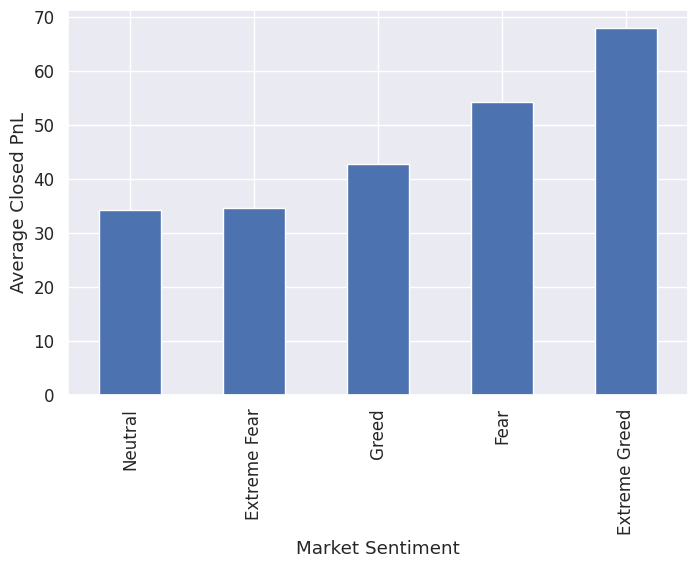

In [25]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.ylabel("Average Closed PnL")

plt.show()

Trading volume

In [26]:
volume = merged.groupby("Market Sentiment")["Size USD"].sum()

volume

,Size USD
Market Sentiment,
Extreme Fear,1.144843e+08
Extreme Greed,1.244652e+08
Fear,4.833248e+08
Greed,2.885825e+08
Neutral,1.802421e+08


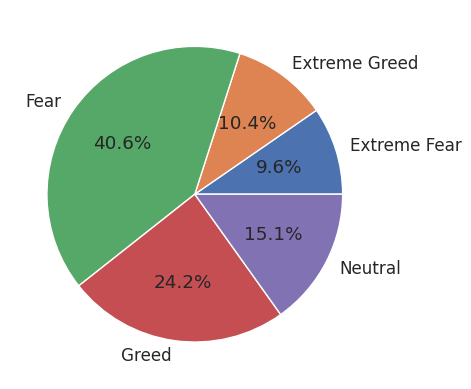

In [27]:
volume.plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.show()

Average leverage

In [28]:
merged.groupby("Market Sentiment")["Start Position"].mean()

,Start Position
Market Sentiment,
Extreme Fear,-2322.304587
Extreme Greed,19518.990812
Fear,8709.824822
Greed,-151088.546635
Neutral,144.002263


Leverage vs PnL

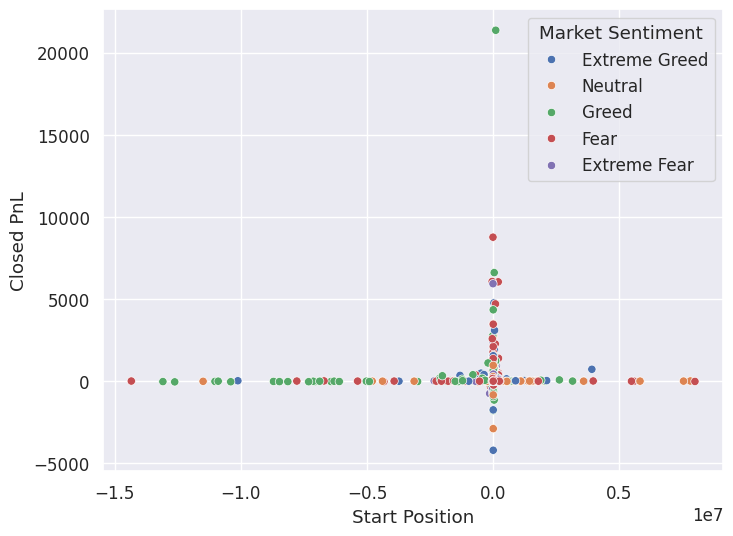

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged.sample(5000),
    x="Start Position",
    y="Closed PnL",
    hue="Market Sentiment"
)

plt.show()

Correlation matrix

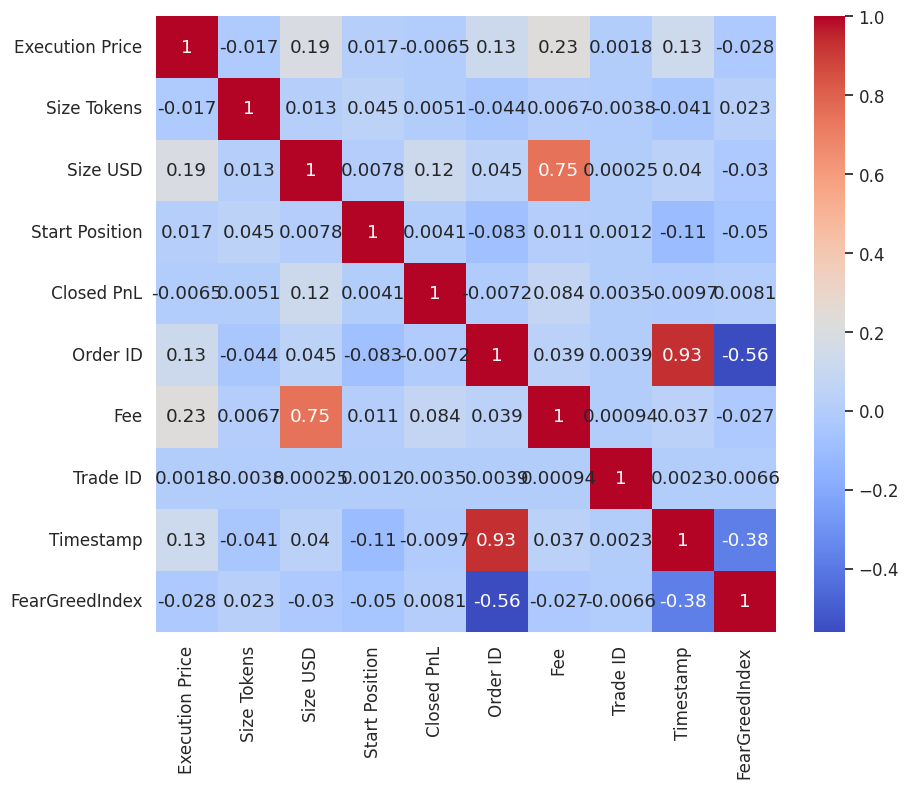

In [30]:
corr = merged.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Daily profit

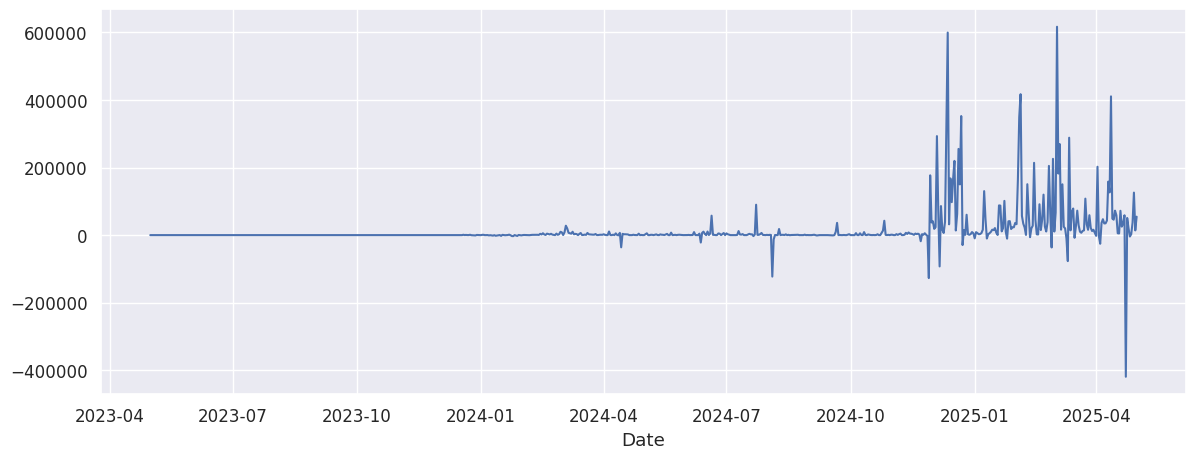

In [31]:
daily = merged.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(14,5))

daily.plot()

plt.show()

Top traders

In [32]:
top = merged.groupby("Account").agg(
    TotalPnL=("Closed PnL","sum"),
    Trades=("Closed PnL","count"),
    AvgPnL=("Closed PnL","mean")
)

top = top.sort_values("TotalPnL",ascending=False)

top.head(20)

,TotalPnL,Trades,AvgPnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733,145.481748
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192,44.364091
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236,68.684419
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184,20.806305
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356,155.589314
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590,270.034947
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237,336.735548
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,1430,281.826227


Save

In [33]:
top.to_csv("top_traders.csv")

Winning ratio

In [34]:
merged["Win"] = merged["Closed PnL"]>0

win_rate = merged.groupby("Market Sentiment")["Win"].mean()*100

win_rate

,Win
Market Sentiment,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


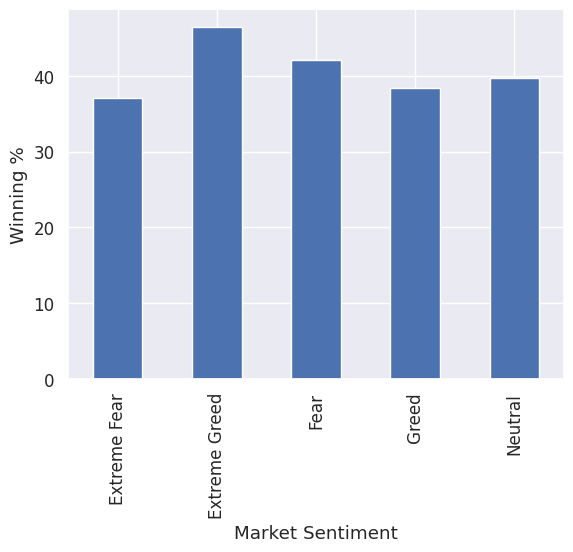

In [35]:
win_rate.plot(kind="bar")

plt.ylabel("Winning %")

plt.show()

Average trade size

In [36]:
merged.groupby("Market Sentiment")["Size USD"].mean()

,Size USD
Market Sentiment,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


Average fee

In [37]:
merged.groupby("Market Sentiment")["Fee"].mean()

,Fee
Market Sentiment,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


Long vs Short

In [38]:
pd.crosstab(
    merged["Market Sentiment"],
    merged["Direction"]
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
Market Sentiment,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


Visualization

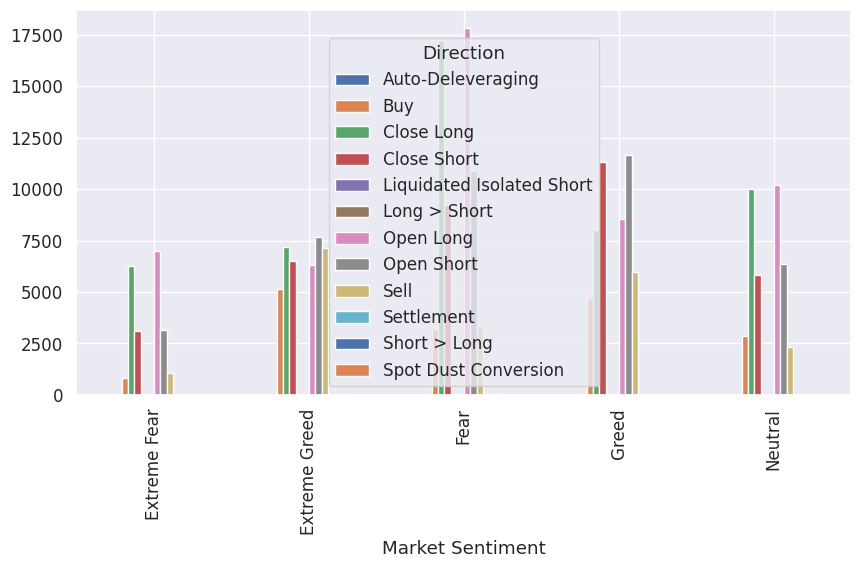

In [39]:
pd.crosstab(
    merged["Market Sentiment"],
    merged["Direction"]
).plot(kind="bar",figsize=(10,5))

plt.show()

Export summaries

In [40]:
summary = merged.groupby("Market Sentiment").agg(
    Trades=("Closed PnL","count"),
    AveragePnL=("Closed PnL","mean"),
    MedianPnL=("Closed PnL","median"),
    TotalPnL=("Closed PnL","sum"),
    AverageTrade=("Size USD","mean"),
    AverageFee=("Fee","mean")
)

summary

,Trades,AveragePnL,MedianPnL,TotalPnL,AverageTrade,AverageFee
Market Sentiment,,,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05,5349.731843,1.116291
Extreme Greed,39992,67.892861,0.0,2.715171e+06,3112.251565,0.675902
Fear,61837,54.290400,0.0,3.357155e+06,7816.109931,1.495172
Greed,50303,42.743559,0.0,2.150129e+06,5736.884375,1.254372
Neutral,37686,34.307718,0.0,1.292921e+06,4782.732661,1.044798


In [41]:
summary.to_csv("sentiment_summary.csv")

Trader summary

In [42]:
trader_summary = merged.groupby("Account").agg(
    Trades=("Closed PnL","count"),
    WinRate=("Win","mean"),
    AvgPnL=("Closed PnL","mean"),
    TotalPnL=("Closed PnL","sum")
)

trader_summary.to_csv("trader_summary.csv")

Profit by Coin

In [46]:
coin_summary = merged.groupby("Coin").agg(
    Total_PnL=("Closed PnL","sum"),
    Average_PnL=("Closed PnL","mean"),
    Trades=("Closed PnL","count")
).sort_values("Total_PnL",ascending=False)

coin_summary.head(15)

,Total_PnL,Average_PnL,Trades
Coin,,,
@107,2.783913e+06,92.821850,29992
HYPE,1.948485e+06,28.652079,68005
SOL,1.639556e+06,153.358519,10691
ETH,1.319979e+06,118.298874,11158
BTC,8.680447e+05,33.304356,26064
MELANIA,3.903511e+05,88.155165,4428
ENA,2.173295e+05,219.524751,990
SUI,1.992688e+05,100.691680,1979
ZRO,1.837778e+05,148.327509,1239


Top Coins Visualization

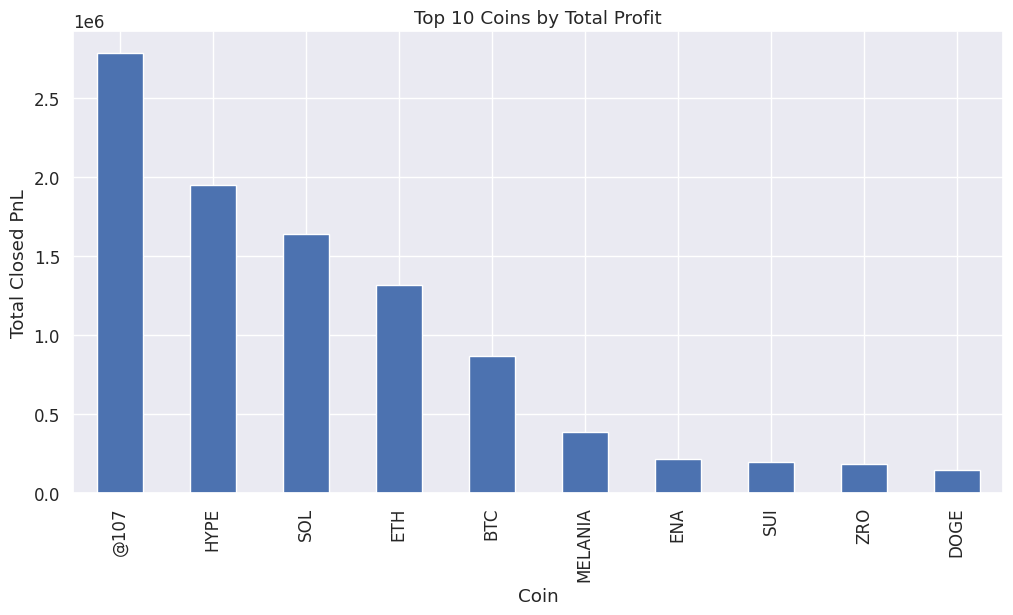

In [47]:
plt.figure(figsize=(12,6))

coin_summary.head(10)["Total_PnL"].plot(kind="bar")

plt.title("Top 10 Coins by Total Profit")
plt.ylabel("Total Closed PnL")

plt.show()

Trading Activity by Hour

In [48]:
merged["Hour"] = merged["Timestamp IST"].dt.hour

hour_summary = merged.groupby("Hour").agg(
    Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean")
)

hour_summary

,Trades,Average_PnL
Hour,,
0,9856,43.126269
1,10481,49.918770
2,8181,34.205399
3,10524,43.711571
4,10015,48.663764
5,9538,40.460611
6,9057,32.983412
7,8585,83.026712
8,7848,58.886420


Hour-wise Trade Count

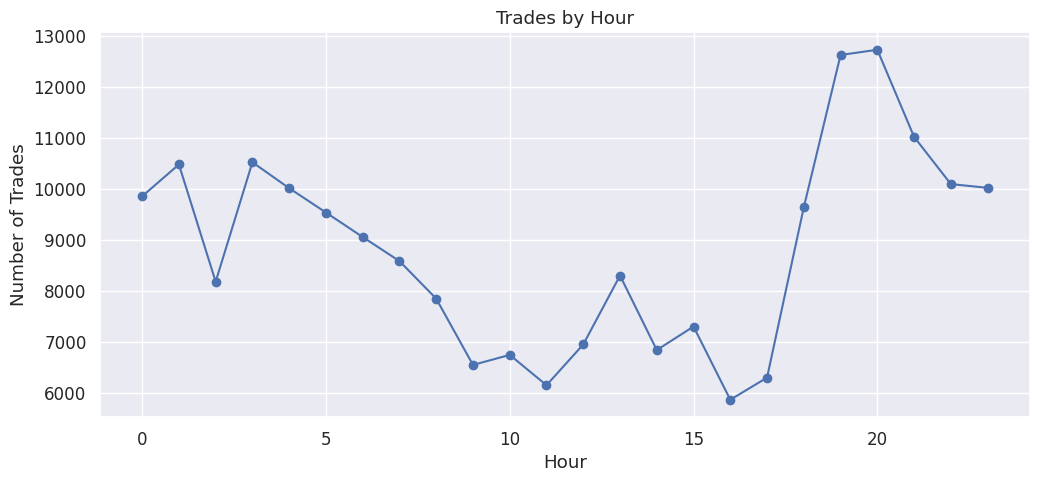

In [49]:
plt.figure(figsize=(12,5))

hour_summary["Trades"].plot(marker='o')

plt.title("Trades by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trades")

plt.grid(True)

plt.show()

Hour-wise Profit

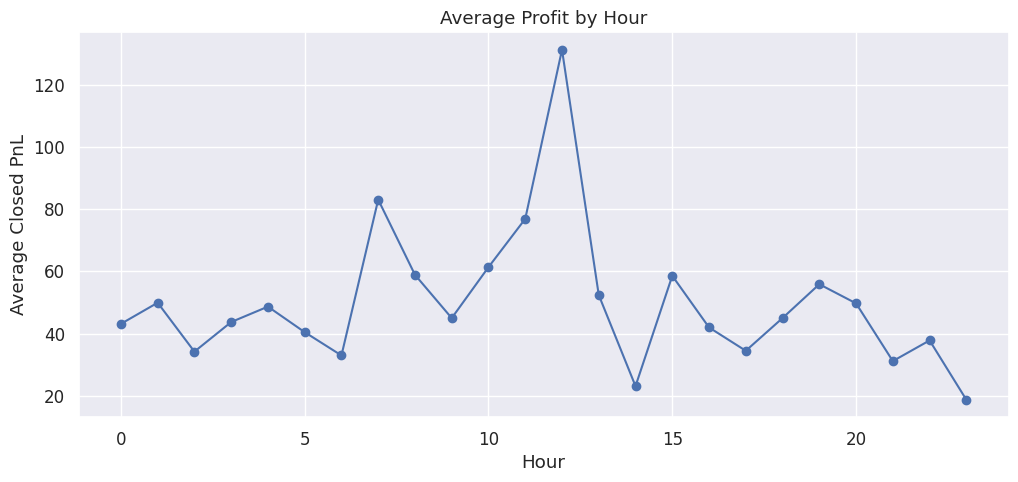

In [50]:
plt.figure(figsize=(12,5))

hour_summary["Average_PnL"].plot(marker='o')

plt.title("Average Profit by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Closed PnL")

plt.grid(True)

plt.show()

Day-wise Analysis

In [51]:
merged["Day"] = merged["Timestamp IST"].dt.day_name()

day_summary = merged.groupby("Day").agg(
    Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean")
)

day_summary = day_summary.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

day_summary

,Trades,Average_PnL
Day,,
Monday,34421,51.086171
Tuesday,36469,47.475549
Wednesday,39736,38.003781
Thursday,30439,46.280620
Friday,29624,50.264482
Saturday,20425,65.364129
Sunday,20110,52.918183


Day-wise Chart

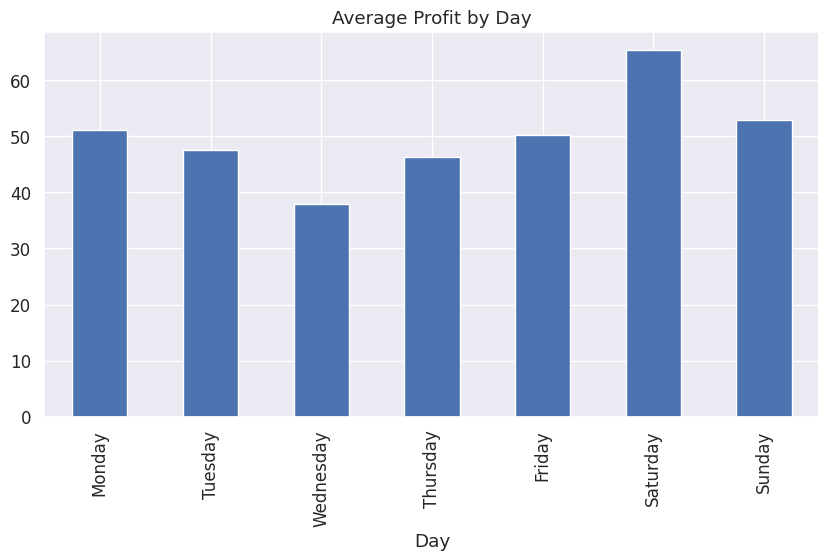

In [52]:
plt.figure(figsize=(10,5))

day_summary["Average_PnL"].plot(kind="bar")

plt.title("Average Profit by Day")

plt.show()

Fee vs Profit

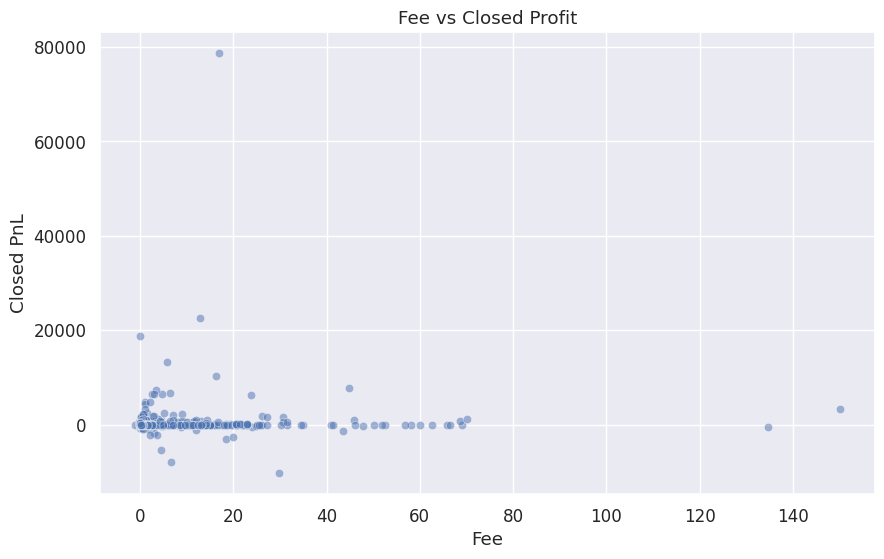

In [53]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged.sample(min(5000,len(merged))),
    x="Fee",
    y="Closed PnL",
    alpha=0.5
)

plt.title("Fee vs Closed Profit")

plt.show()

Boxplot of Profit by Sentiment

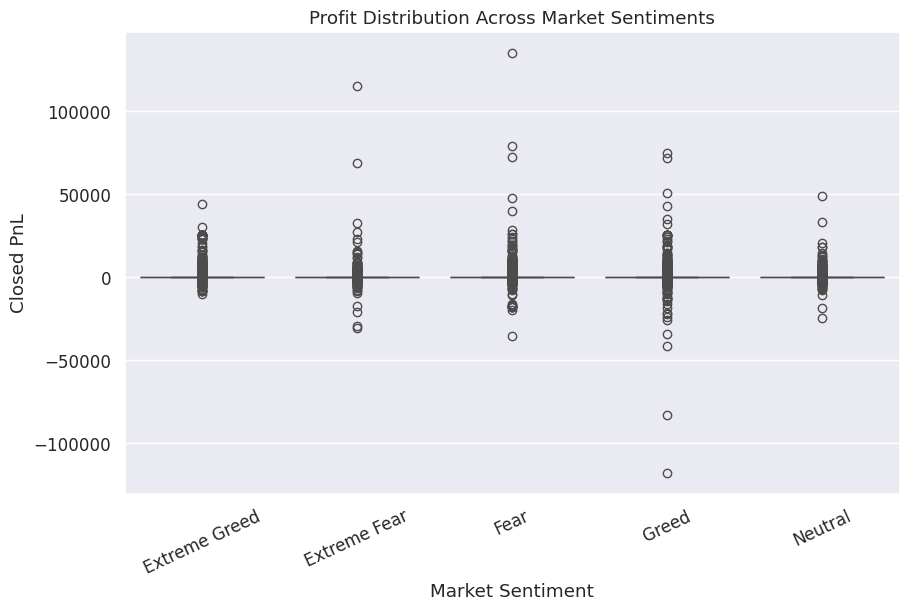

In [54]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="Market Sentiment",
    y="Closed PnL"
)

plt.title("Profit Distribution Across Market Sentiments")

plt.xticks(rotation=25)

plt.show()

Fear & Greed Index vs Profit

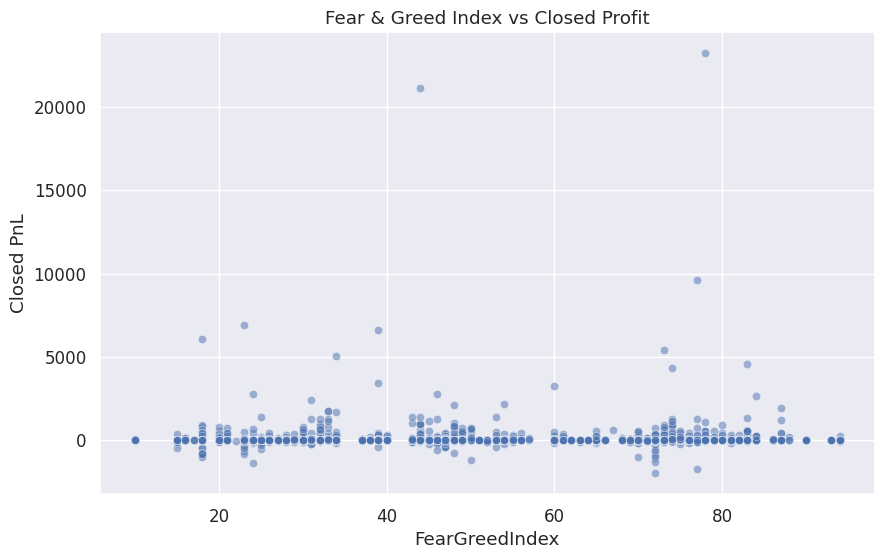

In [55]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged.sample(min(5000,len(merged))),
    x="FearGreedIndex",
    y="Closed PnL",
    alpha=0.5
)

plt.title("Fear & Greed Index vs Closed Profit")

plt.show()

Correlation Matrix

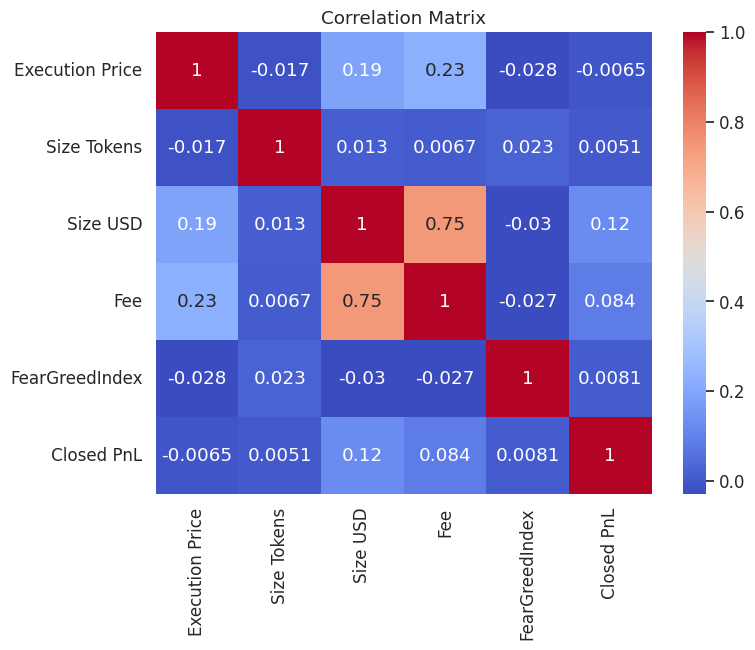

In [56]:
plt.figure(figsize=(8,6))

corr = merged[[
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Fee",
    "FearGreedIndex",
    "Closed PnL"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Top 20 Traders

In [57]:
top_traders = merged.groupby("Account").agg(
    Total_PnL=("Closed PnL","sum"),
    Trades=("Closed PnL","count"),
    Average_PnL=("Closed PnL","mean")
).sort_values("Total_PnL",ascending=False)

top_traders.head(20)

,Total_PnL,Trades,Average_PnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,14733,145.481748
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,419.127768
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,21192,44.364091
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,12236,68.684419
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05,40184,20.806305
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05,4356,155.589314
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05,1590,270.034947
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,1237,336.735548
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05,1430,281.826227


# Key Insights

1. Traders made the highest average profit during the Extreme Greed market condition.

2. The Fear market had the highest total profit because there were more trades during that period.

3. The win rate was highest in Extreme Greed and lowest in Extreme Fear.

4. Traders placed bigger trades during Fear compared to other market conditions.

5. Higher trade sizes also resulted in higher trading fees.

6. Most trades were regular buy and sell positions, while liquidation events happened less often.

7. A few traders earned most of the total profit, while many traders made smaller profits or losses.

8. Overall, market sentiment affected how traders behaved and how much profit they made.

# Conclusion

In this project, I analyzed the relationship between Bitcoin market sentiment and trader performance using the Fear & Greed Index and Hyperliquid trading data.

From the analysis, I found that trader performance changes with different market sentiments. Traders earned the highest average profit during Extreme Greed, while Fear had the highest overall profit because there were more trades. I also observed that traders took larger positions during Fear, which led to higher trading fees.

Overall, this analysis shows that market sentiment has an impact on trading activity and profitability. Using market sentiment along with other trading indicators can help traders make better decisions and manage risk more effectively.